<a href="https://colab.research.google.com/github/Maverixk/contrastive-bridge-3d-vlm/blob/main/CV_Group_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sensor-Aware Contrastive Bridge for Real-World 3D Vision Language Models

## General information

### Students:
- Lorenzo Carlini
- Riccardo Aquilanti
- Luca Di Carlo

### Abstract
Real-world RGB-D sensors such as Microsoft Kinect introduce depth quantization, speckle and missing-pixel artifacts that severely degrade the zero-shot performance of state-of-the-art 3D vision–language models (VLMs) on raw scans, despite strong results on synthetic CAD benchmarks. Existing 3D VLMs like ULIP-2, trained on large-scale synthetic point cloud–image–text triplets, remain mostly sensor-agnostic and show a significant synthetic-
to-real gap on datasets such as ScanObjectNN, while synthetic-to-real approaches like SynVL3D rely on scene-level adversarial training and expensive full-model fine-tuning.

We address sensor-aware synthetic-to-real adaptation for 3D VLMs under Kinect-like noise and use zero-shot 3D object classification strictly as an evaluation protocol rather than the primary task. We propose a Sensor-Aware Contrastive Bridge (SACB): a lightweight PyTorch-based 3-layer MLP that operates on projected multi-view depth features and learns to map noisy Kinect-style point clouds into the latent space of a frozen ULIP-style encoder, trained on ShapeNet-derived synthetic views augmented with a parametric Kinect noise simulator. A Surface-Curvature Hard Negative Sampler selects negatives with similar local geometry but different noise profiles, encouraging noise-robust geometric features.

We will pre-train the bridge on ShapeNet55 and evaluate on ScanObjectNN and ModelNet40 using top-1 accuracy, feature-space Chamfer distance, and ablations over noise model, negative sampling strategy, and bridge depth, reusing public ULIP checkpoints to keep computation feasible within the course constraints.

## Imports

### Libraries

Below, you'll find a cell meant for importing all the libraries we need for our project. Before the imports, we want to install some specific packages that we are going to use. More specifically:
- **open-clip-torch**, essential for CLIP text encoder;
- **huggingface_hub**, required to dynamically download stuff from HuggingFace;
- **h5py**, used to handle the dataset we will import.

In [1]:
# ── Packages install ──────────────────────────────────────────────────────────
!pip install -q open-clip-torch huggingface_hub h5py

# ── Standard libraries ────────────────────────────────────────────────────────
import os
import random
import glob
import json
import zipfile
import urllib.request
import shutil
from collections import OrderedDict

# ── Data management & visualizations ──────────────────────────────────────────
import numpy as np
import h5py
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec

# ── PyTorch ecosystem ─────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset, ConcatDataset
from timm.layers import DropPath

# ── Deep Learning Utilities ───────────────────────────────────────────────────
import open_clip
from huggingface_hub import hf_hub_download, list_repo_files, snapshot_download
from tqdm.notebook import tqdm

# ── Google Colab ──────────────────────────────────────────────────────────────
from google.colab import drive, userdata

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 32.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.8 MB/s eta 0:00:00


### Setup

In this block, we want to create our directory on **Google Drive**, in order to store the datasets we'll use. Moreover, we intend to setup the environment for the use of **CUDA drivers**, as the training phase will mainly be performed with NVIDIA GPUs.

In [2]:
drive.mount('/content/drive')

BASE = '/content/drive/MyDrive/SACB'
for d in ['models', 'data/modelnet40', 'data/scanobjectnn', 'data/shapenetcore', 'checkpoints', 'results']:
    os.makedirs(f'{BASE}/{d}', exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    name = torch.cuda.get_device_name(0)
    vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    AMP_DTYPE = torch.bfloat16 if 'A100' in name or 'A10' in name else torch.float16
    print(f'GPU: {name}  VRAM: {vram:.1f} GB  AMP dtype: {AMP_DTYPE}')
else:
    AMP_DTYPE = torch.float32
    print('WARNING: no GPU')

Mounted at /content/drive
GPU: NVIDIA A100-SXM4-40GB  VRAM: 42.4 GB  AMP dtype: torch.bfloat16


## Globals

### Constants
The following cell contains all the **constants** that will be used in the rest of this notebook.

In [3]:
# ── Paths ─────────────────────────────────────────────────────────────────────
ULIP2_CKPT       = f'{BASE}/models/ulip2_pointbert.pt'
MODELNET40_DIR   = f'{BASE}/data/modelnet40'
SCANOBJECTNN_DIR = f'{BASE}/data/scanobjectnn'
SHAPENET_DIR     = f'{BASE}/data/shapenetcore'
CHECKPOINTS_DIR  = f'{BASE}/checkpoints'
RESULTS_DIR      = f'{BASE}/results'

# ── PointBERT config ──────────────────────────────────────────────────────────
NUM_POINTS  = 2048
NUM_GROUP   = 128   # reduced from 512 (8192-pt model) to suit 2048-pt inputs
GROUP_SIZE  = 32
TRANS_DIM   = 384
DEPTH       = 12
DROP_PATH   = 0.1
NUM_HEADS   = 6
ENC_DIMS    = 256
PC_FEAT_DIM = TRANS_DIM * 2   # 768
FEAT_DIM    = 512             # after pc_projection

# ── Training ──────────────────────────────────────────────────────────────────
SEED          = 42
NUM_EPOCHS    = 30
BATCH_SIZE    = 64      # reduce to 16 on free T4 if OOM
LEARNING_RATE = 1e-3    # put 5e-4 for hidden_dim=2048
WEIGHT_DECAY  = 1e-4    # put 1e-3 for hidden_dim=2048
TEMPERATURE   = 0.15

# ── Noise params ──────────────────────────────────────────────────────────────
KINECT_AXIAL_SIGMA   = 0.0012
KINECT_LATERAL_SIGMA = 0.0019
KINECT_DROPOUT_P     = 0.05
GAUSSIAN_SIGMA       = 0.02

# ── Class labels ──────────────────────────────────────────────────────────────
SCANOBJECTNN_CLASSES = [
    'bag','bin','box','cabinet','chair',
    'desk','display','door','shelf','table',
    'bed','pillow','sink','sofa','toilet',
]

MN40_CLASSES = [
    'airplane','bathtub','bed','bench','bookshelf','bottle','bowl','car','chair',
    'cone','cup','curtain','desk','door','dresser','flower pot','glass box',
    'guitar','keyboard','lamp','laptop','mantel','monitor','night stand','person',
    'piano','plant','radio','range hood','sink','sofa','stairs','stool','table',
    'tent','toilet','tv stand','vase','wardrobe','xbox',
]

# Richer descriptions to avoid text-space degeneracy (e.g. desk/table similarity)
CLASS_DESCS = {
    'bag':'bag','bin':'trash bin','box':'cardboard box',
    'cabinet':'storage cabinet','chair':'chair','desk':'office desk',
    'display':'computer monitor','door':'door','shelf':'bookshelf',
    'table':'dining table','bed':'bed','pillow':'pillow',
    'sink':'sink','sofa':'sofa couch','toilet':'toilet',
}

PROMPT_TEMPLATES = [
    'a 3D scan of a {}',
    'a point cloud of a {}',
    'a {} in an indoor scene',
    '{}',
]


# ── ShapeNet class labels ─────────────────────────────────────────────────────
SHAPENET_CLASSES = [
    'table', 'jar', 'skateboard', 'car', 'bottle', 'tower', 'chair',
    'bookshelf', 'camera', 'airplane', 'laptop', 'basket', 'sofa', 'knife',
    'can', 'rifle', 'train', 'pillow', 'lamp', 'trash bin', 'mailbox',
    'watercraft', 'motorbike', 'dishwasher', 'bench', 'pistol', 'rocket',
    'loudspeaker', 'file cabinet', 'bag', 'cabinet', 'bed', 'birdhouse',
    'display', 'piano', 'earphone', 'telephone', 'stove', 'microphone',
    'bus', 'mug', 'remote', 'bathtub', 'bowl', 'keyboard', 'guitar',
    'washer', 'bicycle', 'faucet', 'printer', 'cap',
]

# Synset folder/zip names → index in SHAPENET_CLASSES (used by HDF5 builder)
_SYNSET_TO_CLASSNAME = {
    '02691156': 'airplane',    '02747177': 'trash bin',   '02773838': 'bag',
    '02801938': 'basket',      '02808440': 'bathtub',     '02818832': 'bed',
    '02828884': 'bench',       '02843684': 'birdhouse',   '02871439': 'bookshelf',
    '02876657': 'bottle',      '02880940': 'bowl',        '02924116': 'bus',
    '02933112': 'cabinet',     '02942699': 'camera',      '02946921': 'can',
    '02954340': 'cap',         '02958343': 'car',         '02992529': 'telephone',
    '03001627': 'chair',       '03046257': 'train',       '03085013': 'keyboard',
    '03207941': 'dishwasher',  '03211117': 'display',     '03261776': 'earphone',
    '03325088': 'faucet',      '03337140': 'file cabinet','03467517': 'guitar',
    '03593526': 'jar',         '03624134': 'knife',       '03636649': 'lamp',
    '03642806': 'laptop',      '03691459': 'loudspeaker', '03710193': 'mailbox',
    '03759954': 'microphone',  '03790512': 'motorbike',   '03797390': 'mug',
    '03928116': 'piano',       '03938244': 'pillow',      '03948459': 'pistol',
    '04004475': 'printer',     '04074963': 'remote',      '04090263': 'rifle',
    '04099429': 'rocket',      '04225987': 'skateboard',  '04256520': 'sofa',
    '04330267': 'stove',       '04379243': 'table',       '04401088': 'telephone',
    '04460130': 'tower',       '04468005': 'train',       '04530566': 'watercraft',
    '04554684': 'washer',
}
SYNSET_TO_IDX = {
    sid: SHAPENET_CLASSES.index(cls)
    for sid, cls in _SYNSET_TO_CLASSNAME.items()
    if cls in SHAPENET_CLASSES
}

random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
print('Constants loaded.')

Constants loaded.


## Utils

### Point cloud utilities
Below we will include the **utility functions** meant for dealing with the **point clouds**.

In [4]:
# ── FPS (pure PyTorch, no compiled CUDA extension) ───────────────────────────
def _index_points(points, idx):
    B = points.shape[0]
    view = [1] * idx.dim(); view[0] = B
    bidx = torch.arange(B, device=points.device).view(view).expand_as(idx)
    return points[bidx, idx, :]

def fps(xyz, npoint):
    """Furthest Point Sampling, (B,N,3) -> (B,npoint,3)"""
    B, N, _ = xyz.shape
    centroids = torch.zeros(B, npoint, dtype=torch.long, device=xyz.device)
    dist      = torch.full((B, N), 1e10, device=xyz.device)
    farthest  = torch.randint(0, N, (B,), device=xyz.device)
    bidx      = torch.arange(B, device=xyz.device)
    for i in range(npoint):
        centroids[:, i] = farthest
        centroid = xyz[bidx, farthest].unsqueeze(1)   # B 1 3
        d = ((xyz - centroid) ** 2).sum(-1)
        dist = torch.minimum(dist, d)
        farthest = dist.argmax(-1)
    return _index_points(xyz, centroids)

def _square_dist(src, dst):
    B, N, _ = src.shape; _, M, _ = dst.shape
    d  = -2 * torch.matmul(src, dst.permute(0,2,1))
    d +=  src.pow(2).sum(-1).view(B, N, 1)
    d +=  dst.pow(2).sum(-1).view(B, 1, M)
    return d

def knn_point(nsample, xyz, new_xyz):
    """(B,N,3),(B,S,3) -> (B,S,nsample) indices"""
    _, idx = torch.topk(_square_dist(new_xyz, xyz), nsample, dim=-1, largest=False, sorted=False)
    return idx

# ── Grouping + mini-encoder (PointBERT tokeniser) ─────────────────────────────
class Group(nn.Module):
    def __init__(self, num_group, group_size):
        super().__init__()
        self.num_group  = num_group
        self.group_size = group_size

    def forward(self, xyz):
        B, N, _ = xyz.shape
        center   = fps(xyz, self.num_group)                      # B G 3
        idx      = knn_point(self.group_size, xyz, center)       # B G M
        idx_flat = (idx + torch.arange(B, device=xyz.device).view(-1,1,1)*N).view(-1)
        nb = xyz.view(B*N, 3)[idx_flat].view(B, self.num_group, self.group_size, 3)
        nb = nb - center.unsqueeze(2)                            # local coords
        return nb, center

class PatchEncoder(nn.Module):
    """Per-group PointNet: (B,G,M,3) -> (B,G,encoder_dims)"""
    def __init__(self, encoder_dims):
        super().__init__()
        self.encoder_dims = encoder_dims
        self.first_conv  = nn.Sequential(nn.Conv1d(3,128,1), nn.BatchNorm1d(128), nn.ReLU(True), nn.Conv1d(128,256,1))
        self.second_conv = nn.Sequential(nn.Conv1d(512,512,1), nn.BatchNorm1d(512), nn.ReLU(True), nn.Conv1d(512,encoder_dims,1))

    def forward(self, groups):
        B, G, M, _ = groups.shape
        x  = groups.reshape(B*G, M, 3)
        f  = self.first_conv(x.transpose(2,1))                       # BG 256 M
        fg = f.max(2, keepdim=True)[0]                          # BG 256 1
        f  = self.second_conv(torch.cat([fg.expand(-1,-1,M), f], 1)) # BG D M
        return f.max(2)[0].reshape(B, G, self.encoder_dims)     # B G D

print('Utilities defined.')

Utilities defined.


### Noise & curvature utilities
Our task requires us to deal with different **types of noise**, so it is optimal to create and group their specific utilities all together.

In [5]:
def apply_gaussian_noise(pc):
    return pc + torch.randn_like(pc) * GAUSSIAN_SIGMA

def apply_kinect_noise(pc,
                       base_dropout_p=0.02,
                       depth_dropout_scale=0.10,
                       hole_seed_p=0.015,
                       hole_k=24,
                       axial_sigma=KINECT_AXIAL_SIGMA,
                       lateral_sigma=KINECT_LATERAL_SIGMA,
                       holes=False):
    B, N, _ = pc.shape
    device = pc.device

    # --- Random view direction (vectorized over batch) ---
    view = torch.randn(B, 3, device=device)
    view = view / (view.norm(dim=-1, keepdim=True) + 1e-8)  # (B, 3)

    # Depth proxy along random view
    depth = (pc * view.unsqueeze(1)).sum(-1)  # (B, N)
    depth = depth - depth.min(dim=1, keepdim=True).values
    depth = depth / (depth.max(dim=1, keepdim=True).values + 1e-8)  # (B, N) in [0,1]

    # Axial noise (along view)
    axial_mag = axial_sigma * (0.25 + depth ** 2)            # (B, N)
    axial_noise = (torch.randn(B, N, device=device) * axial_mag).unsqueeze(-1) \
                  * view.unsqueeze(1)                         # (B, N, 3)

    # Lateral noise, quick orthogonal basis via cross product
    up = torch.zeros(B, 3, device=device)
    up[:, 1] = 1.0
    # Swap to [1,0,0] for views aligned with Y
    aligned = (view * up).sum(-1).abs() > 0.9
    up[aligned] = torch.tensor([1., 0., 0.], device=device)

    e1 = torch.cross(view, up, dim=-1)
    e1 = e1 / (e1.norm(dim=-1, keepdim=True) + 1e-8)        # (B, 3)
    e2 = torch.cross(view, e1, dim=-1)
    e2 = e2 / (e2.norm(dim=-1, keepdim=True) + 1e-8)        # (B, 3)

    lat_mag = lateral_sigma * (0.25 + depth)                 # (B, N)
    lat1 = (torch.randn(B, N, device=device) * lat_mag).unsqueeze(-1) * e1.unsqueeze(1)
    lat2 = (torch.randn(B, N, device=device) * lat_mag).unsqueeze(-1) * e2.unsqueeze(1)

    noisy = pc + axial_noise + lat1 + lat2                   # (B, N, 3)

    # --- Depth-dependent iid dropout ---
    drop_prob = base_dropout_p + depth_dropout_scale * depth  # (B, N)
    keep = torch.rand(B, N, device=device) > drop_prob        # (B, N)

    # --- Vectorized hole dropout (approximate, avoids cdist loop) ---
    # Seed a fraction of points, then knock out their k-NN using a fast ball query
    if holes:
        seed_mask = torch.rand(B, N, device=device) < hole_seed_p  # (B, N)
        if seed_mask.any():
            # Pairwise L2 squared, only compute if seeds exist; cap memory with chunking if needed
            diff = pc.unsqueeze(2) - pc.unsqueeze(1)              # (B, N, N, 3)
            d2 = (diff ** 2).sum(-1)                              # (B, N, N)
            # For each point, find if it's among the hole_k nearest to any seed
            seed_d2 = d2 * seed_mask.unsqueeze(2).float() + \
                    (~seed_mask).unsqueeze(2).float() * 1e9     # mask non-seeds to inf
            min_seed_d2 = seed_d2.min(dim=1).values               # (B, N) dist to nearest seed
            # Kill the hole_k closest to each seed, threshold by the hole_k-th distance
            kth_dist = min_seed_d2.kthvalue(min(hole_k, N), dim=1).values  # (B,)
            in_hole = min_seed_d2 <= kth_dist.unsqueeze(1)        # (B, N)
            keep = keep & ~in_hole

    # Fallback: replace dropped points with nearest surviving point (or first point)
    fallback = noisy[:, 0:1, :].expand_as(noisy)
    keep_mask = keep.unsqueeze(-1)                            # (B, N, 1)
    noisy_out = torch.where(keep_mask, noisy, fallback)

    return noisy_out, keep_mask

def batch_curvatures(pc):
    """(B,N,3) -> (B,) curvature proxy via smallest PCA eigenvalue ratio."""
    B, N, _ = pc.shape
    idx = torch.randint(0, N, (B, min(256, N)), device=pc.device)
    sub = pc[torch.arange(B).unsqueeze(1), idx]
    sub = sub - sub.mean(1, keepdim=True)
    cov = sub.transpose(1,2) @ sub / sub.shape[1]
    eigs = torch.linalg.eigvalsh(cov.float()).clamp(min=0)
    return eigs[:,0] / (eigs.sum(-1) + 1e-8)

def sc_hns_mask(curvatures, delta=0.05):
    """(B,) -> (B,B) float mask: 1 where curvature difference < delta (hard negatives)."""
    diff = (curvatures.unsqueeze(1) - curvatures.unsqueeze(0)).abs()
    mask = (diff < delta).float()
    mask.fill_diagonal_(0)
    return mask

print('Noise utilities defined.')

Noise utilities defined.


### Training utilities

In [6]:
def info_nce(bridged, clean, tau):
    b = F.normalize(bridged, dim=1); c = F.normalize(clean, dim=1)
    logits = (b @ c.T) / tau
    return F.cross_entropy(logits, torch.arange(logits.size(0), device=logits.device))

def info_nce_schns(bridged, clean, curvs, tau, delta=0.02, penalty_weight=0.5):
    b = F.normalize(bridged, dim=1); c = F.normalize(clean, dim=1)
    logits = (b @ c.T) / tau + sc_hns_mask(curvs, delta) * penalty_weight
    return F.cross_entropy(logits, torch.arange(logits.size(0), device=logits.device))

class Trainer:
    def __init__(self, variant, encoder):
        assert variant in ('A','B','C')
        self.variant   = variant
        self.encoder   = encoder
        self.use_schns = variant in ('B','C')
        self.bridge    = SensorAwareContrastiveBridge().to(device)
        self.optimizer = optim.AdamW(self.bridge.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

        # 1. Warmup: starts at 1% of the learning rate and linearly scales to 100% over 5 epochs
        warmup_scheduler = optim.lr_scheduler.LinearLR(
            self.optimizer, start_factor=0.01, end_factor=1.0, total_iters=5
        )

        # 2. Cosine decay: takes over for the remaining epochs (NUM_EPOCHS - 5)
        cosine_scheduler = optim.lr_scheduler.CosineAnnealingLR(
            self.optimizer, T_max=(NUM_EPOCHS - 5), eta_min=1e-6
        )

        # 3. Chain them together using SequentialLR
        self.scheduler = optim.lr_scheduler.SequentialLR(
            self.optimizer,
            schedulers=[warmup_scheduler, cosine_scheduler],
            milestones=[5]
        )

        self.scaler    = torch.amp.GradScaler('cuda')
        self.history   = []
        print(f'[Trainer] variant={variant}  bridge params={self.bridge.count_parameters():,}')

    def train_epoch(self, loader):
        self.bridge.train()
        total = 0.0
        for clean_pc, noisy_pc in tqdm(loader, leave=False):
            clean_pc = clean_pc.to(device, non_blocking=True)
            noisy_pc = noisy_pc.to(device, non_blocking=True)
            with torch.no_grad():
                clean_f = self.encoder.encode_pc(clean_pc)
                noisy_f = self.encoder.encode_pc(noisy_pc)
            curvs = batch_curvatures(clean_pc) if self.use_schns else None
            self.optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast('cuda', dtype=AMP_DTYPE):
                br = self.bridge(noisy_f)
                loss = info_nce_schns(br, clean_f, curvs, TEMPERATURE) if self.use_schns else info_nce(br, clean_f, TEMPERATURE)
            self.scaler.scale(loss).backward()
            self.scaler.unscale_(self.optimizer)
            torch.nn.utils.clip_grad_norm_(self.bridge.parameters(), max_norm=1.0)
            self.scaler.step(self.optimizer); self.scaler.update()
            total += loss.item()

        # Handles both the warmup and the cosine transition
        self.scheduler.step()

        avg = total / max(len(loader), 1)
        self.history.append(avg)
        return avg

    def save(self, epoch):
        path = f'{CHECKPOINTS_DIR}/sacb_variant{self.variant}_epoch{epoch:03d}.pt'
        torch.save({'epoch':epoch,'variant':self.variant,
                    'bridge_state':self.bridge.state_dict(),'loss':self.history}, path)
        return path

print('Trainer defined.')

Trainer defined.


### Evaluation utilities

In [7]:
@torch.no_grad()
def evaluate(bridge, encoder, loader, classes, variant='C'):
    """Returns (overall_acc %, per_class_acc array, mean_cd)."""
    if loader is None:
        return None, None, None

    descs  = [CLASS_DESCS.get(c, c) for c in classes] if classes is SCANOBJECTNN_CLASSES else None
    text_f = encoder.encode_text(classes, descs).to(device)
    preds, lbls, cds = [], [], []

    for pc, lbl in loader:
        pc      = pc.to(device)
        clean_f = encoder.encode_pc(pc)           # reference, always clean

        # Apply the same noise as training so the bridge sees its expected input
        if variant == 'A':
            noisy_pc = apply_gaussian_noise(pc)
        elif variant == 'C':
            noisy_pc, keep_mask = apply_kinect_noise(pc)
            noisy_pc = torch.where(keep_mask.expand_as(noisy_pc), noisy_pc, pc)
        else:                                      # variant B, no noise
            noisy_pc = pc

        noisy_f = encoder.encode_pc(noisy_pc)

        if bridge is not None:
            feat = F.normalize(bridge(noisy_f), dim=1)
            # CD: how close did the bridge get back to clean feature space
            cds.append((feat - F.normalize(clean_f, dim=1)).norm(dim=1).mean().item())
        else:
            feat = F.normalize(noisy_f, dim=1)
            # CD: how far did noise push features from clean
            cds.append((feat - F.normalize(clean_f, dim=1)).norm(dim=1).mean().item())

        preds.append((feat @ text_f.T).argmax(1).cpu())
        lbls.append(lbl)

    pred    = torch.cat(preds).numpy()
    label   = torch.cat(lbls).numpy()
    acc     = (pred == label).mean() * 100
    per_cls = np.array([
        (pred[label == c] == c).mean() * 100 if (label == c).any() else 0.0
        for c in range(len(classes))
    ])
    cd = float(np.mean(cds)) if cds else 0.0
    return acc, per_cls, cd

def load_bridge(path):
    bridge = SensorAwareContrastiveBridge().to(device).eval()
    ckpt   = torch.load(path, map_location=device, weights_only=False)
    bridge.load_state_dict(ckpt['bridge_state'])
    return bridge

print('Evaluate defined.')

Evaluate defined.


## Data

### Datasets
The underlying cell defines the objects for the 3 datasets we will use:
- **ModelNet40**;
- **ScanObjectNN**;
- **ShapeNetCore**.

Additionally, there are also 2 **support functions** meant for **normalizing** the point clouds and creating the **train and test set** of each dataset.

In [8]:
def normalize_pc(pc):
    pc = pc - pc.mean(0)
    return pc / (pc.norm(dim=-1).max() + 1e-8)

def _load_obj_vertices(path):
    """Parse XYZ vertices from an OBJ file without extra dependencies."""
    verts = []
    with open(path, 'r', errors='ignore') as f:
        for line in f:
            if line.startswith('v '):
                parts = line.split()
                if len(parts) >= 4:
                    verts.append((float(parts[1]), float(parts[2]), float(parts[3])))
    return np.array(verts, dtype=np.float32) if verts else None

class ModelNet40Dataset(Dataset):
    """Loads ModelNet40 from PointNet HDF5 files (freely available, no registration)."""
    def __init__(self, data_dir, split='train'):
        files = sorted(glob.glob(f'{data_dir}/ply_data_{split}*.h5'))
        if not files:
            raise FileNotFoundError(f'No HDF5 files at {data_dir}/ply_data_{split}*.h5')
        pcs, labels = [], []
        for f in files:
            with h5py.File(f, 'r') as h:
                pcs.append(h['data'][:, :NUM_POINTS, :3].astype(np.float32))
                labels.append(h['label'][:].flatten().astype(np.int64))
        self.pcs    = np.concatenate(pcs)
        self.labels = np.concatenate(labels)

    def __len__(self): return len(self.pcs)
    def __getitem__(self, i):
        return normalize_pc(torch.from_numpy(self.pcs[i])), int(self.labels[i])

class ScanObjectNNDataset(Dataset):
    """Loads ScanObjectNN OBJ_ONLY split."""
    def __init__(self, split='test'):
        path = f'{SCANOBJECTNN_DIR}/{split}_objectdataset.h5'
        if not os.path.exists(path):
            raise FileNotFoundError(
                f'ScanObjectNN not found at {path}\n'
                'Download from https://hkust-vgd.github.io/scanobjectnn/ '
                'and place at Drive/SACB/data/scanobjectnn/')
        with h5py.File(path, 'r') as h:
            self.pcs    = h['data'][:, :NUM_POINTS, :3].astype(np.float32)
            self.labels = h['label'][:].flatten().astype(np.int64)

    def __len__(self): return len(self.pcs)
    def __getitem__(self, i):
        return normalize_pc(torch.from_numpy(self.pcs[i])), int(self.labels[i])

class ShapeNetCoreDataset(Dataset):
    """Loads ShapeNetCore point clouds from the pre-processed HDF5.
    Build the HDF5 once with the pre-processing cell; loading is then fast."""
    def __init__(self, shapenet_dir):
        h5_path = f'{shapenet_dir}/shapenetcore_pcs.h5'
        if not os.path.exists(h5_path):
            raise FileNotFoundError(
                f'ShapeNetCore HDF5 not found at {h5_path}\n'
                'Run the Downloads cell and then the pre-processing cell first.')
        with h5py.File(h5_path, 'r') as f:
            self.pcs = f['data'][:]                      # (N, NUM_POINTS, 3)
            # Older HDF5 builds didn't store labels — fall back gracefully so
            # the dataset still loads, but evaluate() will give meaningless results.
            if 'label' in f:
                self.labels = f['label'][:].flatten().astype(np.int64)
            else:
                print('WARNING: ShapeNetCore HDF5 has no label dataset. '
                      'Delete it and re-run the pre-processing cell to rebuild with labels.')
                self.labels = np.zeros(len(self.pcs), dtype=np.int64)
        print(f'ShapeNetCore: {len(self.pcs):,} point clouds loaded from HDF5')

    def __len__(self): return len(self.pcs)
    def __getitem__(self, i):
        return normalize_pc(torch.from_numpy(self.pcs[i])), int(self.labels[i])

class ContrastivePairDataset(Dataset):
    """Wraps a dataset to return (clean_pc, noisy_pc) pairs."""
    def __init__(self, base, variant):
        self.base = base; self.variant = variant

    def __len__(self): return len(self.base)
    def __getitem__(self, i):
        pc, _ = self.base[i]
        if   self.variant == 'A': noisy = apply_gaussian_noise(pc.unsqueeze(0)).squeeze(0)
        elif self.variant == 'C':
            noisy, keep_mask = apply_kinect_noise(pc.unsqueeze(0))
            noisy = noisy.squeeze(0)
        else:                     noisy = pc.clone()   # variant B: no noise
        return pc, noisy

def get_dataloaders(variant, num_workers=2):
    # Training source: ModelNet40 + ScanObjectNN(training split) + ShapeNetCore
    # (minus whatever's held out for its own eval below). Mixing all three means
    # the bridge sees synthetic CAD geometry (ModelNet/ShapeNet) AND real scanned
    # geometry (ScanObjectNN) during training, instead of only CAD models.
    train_sources = []

    mn40_train = ModelNet40Dataset(MODELNET40_DIR, 'train')
    train_sources.append(mn40_train)
    print(f'Training source: MODELNET40 ({len(mn40_train):,} objects)')

    try:
        scan_train = ScanObjectNNDataset('training')
        train_sources.append(scan_train)
        print(f'Training source: SCANOBJECTNN ({len(scan_train):,} objects)')
    except FileNotFoundError as e:
        print(f'WARNING: no ScanObjectNN training split found, skipping it for training. ({e})')

    # ShapeNet needs special handling: the same filtered pool is also used for
    # eval below, so we split it once here into a disjoint eval subset (same
    # sampling as before, for comparable numbers) and a training pool with
    # everything that's left over.
    shapenet_eval = None
    try:
        shapenet_full = ShapeNetCoreDataset(SHAPENET_DIR)
        shapenet_eval, shapenet_train = get_filtered_shapenet_train_eval(
            shapenet_full,
            shapenet_class_names=SHAPENET_CLASSES,
            mn40_classes=MN40_CLASSES,
            scanobj_classes=SCANOBJECTNN_CLASSES,
        )
        train_sources.append(shapenet_train)
        print(f'Training source: SHAPENETCORE ({len(shapenet_train):,} objects)')
    except FileNotFoundError as e:
        print(f'WARNING: {e}')

    # Wrap each source with its own ContrastivePairDataset instead of concatenating
    # raw datasets and wrapping once. This lets us apply the variant's noise model
    # (Gaussian/Kinect) only to the synthetic CAD sources (ModelNet40, ShapeNet),
    # while ScanObjectNN — already real scanned, noisy geometry — is paired as
    # clean==noisy ('B'-style, no synthetic noise added), regardless of VARIANT.
    pair_sources = []
    for src in train_sources:
        src_variant = 'B' if isinstance(src, ScanObjectNNDataset) else variant
        pair_sources.append(ContrastivePairDataset(src, src_variant))

    train_pairs = pair_sources[0] if len(pair_sources) == 1 else ConcatDataset(pair_sources)
    train_loader = DataLoader(train_pairs,
                              BATCH_SIZE, shuffle=True, num_workers=num_workers,
                              pin_memory=True, drop_last=True)

    try:
        mn40_test   = ModelNet40Dataset(MODELNET40_DIR, 'test')
        mn40_loader = DataLoader(mn40_test, BATCH_SIZE, shuffle=False, num_workers=num_workers)
    except FileNotFoundError as e:
        print(f'WARNING: ModelNet40 not found, run the Downloads cell. ({e})')
        mn40_loader = None
    try:
        scan_ds = ScanObjectNNDataset('test')
        scan_loader = DataLoader(scan_ds, BATCH_SIZE, shuffle=False, num_workers=num_workers)
    except FileNotFoundError as e:
        print(f'WARNING: {e}'); scan_loader = None

    shapenet_loader = (DataLoader(shapenet_eval, BATCH_SIZE, shuffle=False, num_workers=num_workers)
                        if shapenet_eval is not None else None)

    return train_loader, scan_loader, mn40_loader, shapenet_loader

print('Datasets defined.')

Datasets defined.


### Downloads
The following cell will try to **download** the aforementioned datasets. Notice that **ScanObjectNN** requires a **registration** to be downloaded, and ShapenetCore requires HuggingFace access approvale from ShapeNet (gated dataset).

In [9]:
# ── ModelNet40 HDF5 ───────────────────────────────────────────────────────────
if not os.path.exists(f'{MODELNET40_DIR}/ply_data_train0.h5'):
    print('Downloading ModelNet40 HDF5 from HuggingFace…')
    tmp = '/tmp/mn40_hf'
    snapshot_download(
        repo_id='Msun/modelnet40',
        repo_type='dataset',
        revision='d5dc795541800feeb7a4b3bd3142729a0d2adf7a',
        local_dir=tmp,
    )
    # Repo contains modelnet40_ply_hdf5_2048.zip, extract H5 files from it
    inner_zip = f'{tmp}/modelnet40_ply_hdf5_2048.zip'
    with zipfile.ZipFile(inner_zip) as z:
        for member in z.namelist():
            if member.endswith('.h5'):
                with z.open(member) as src, \
                     open(f'{MODELNET40_DIR}/{os.path.basename(member)}', 'wb') as dst:
                    dst.write(src.read())
    shutil.rmtree(tmp, ignore_errors=True)
    print('ModelNet40 ready.')
else:
    print('ModelNet40 already downloaded.')

# ── ScanObjectNN ──────────────────────────────────────────────────────────────
if os.path.exists(f'{SCANOBJECTNN_DIR}/test_objectdataset.h5'):
    print('ScanObjectNN found.')
else:
    print('ScanObjectNN not found, attempting download...')
    SCANOBJECTNN_URL = 'https://hkust-vgd.ust.hk/scanobjectnn/h5_files.zip'
    zip_path = os.path.join(SCANOBJECTNN_DIR, 'h5_files.zip')
    try:
        os.makedirs(SCANOBJECTNN_DIR, exist_ok=True)
        print(f'Downloading {SCANOBJECTNN_URL} ...')
        urllib.request.urlretrieve(SCANOBJECTNN_URL, zip_path)
        print('Download complete. Extracting...')
        with zipfile.ZipFile(zip_path, 'r') as z:
            targets = {'test_objectdataset.h5', 'training_objectdataset.h5'}
            for member in z.namelist():
                if member.startswith('h5_files/main_split/') and os.path.basename(member) in targets:
                    with z.open(member) as src, \
                         open(os.path.join(SCANOBJECTNN_DIR, os.path.basename(member)), 'wb') as dst:
                        dst.write(src.read())
        os.remove(zip_path)
        print('ScanObjectNN ready.')
    except Exception as e:
        print(f'Auto-download failed: {e}')
        print("""
            To add ScanObjectNN manually:
              1. Download h5_files.zip from https://hkust-vgd.ust.hk/scanobjectnn/h5_files.zip
              2. Extract and upload:
                 MyDrive/SACB/data/scanobjectnn/test_objectdataset.h5
                 MyDrive/SACB/data/scanobjectnn/training_objectdataset.h5
            Then re-run this cell.
            """)

# ── ShapeNetCore ──────────────────────────────────────────────────────────────
# The HuggingFace repo distributes one zip per synset category. We store the
# zips on Drive and defer extraction to the pre-processing cell below, which
# extracts each zip to local /tmp/ and writes a single HDF5 to Drive.
# Writing many small OBJ files directly to Drive would be prohibitively slow.
_shapenet_h5   = f'{SHAPENET_DIR}/shapenetcore_pcs.h5'
_shapenet_zips = sorted(glob.glob(f'{SHAPENET_DIR}/zips/*.zip'))

if os.path.exists(_shapenet_h5):
    print('ShapeNetCore HDF5 found, ready to use.')
elif _shapenet_zips:
    print(f'ShapeNetCore zips found ({len(_shapenet_zips)} synsets). Run the pre-processing cell next.')
else:
    try:
        HF_TOKEN = userdata.get('HF_TOKEN')
        if not HF_TOKEN:
            raise ValueError('HF_TOKEN not set in Colab Secrets.')

        zip_dir = f'{SHAPENET_DIR}/zips'
        os.makedirs(zip_dir, exist_ok=True)

        print('Downloading ShapeNetCore zip archives from HuggingFace...')
        snapshot_download(
            repo_id='ShapeNet/ShapeNetCore',
            repo_type='dataset',
            local_dir=zip_dir,
            token=HF_TOKEN,
        )
        print('Download complete. Run the pre-processing cell to build the HDF5.')

    except Exception as e:
        print(f'Auto-download failed: {e}')
        print("""
            ShapeNetCore is a gated dataset, access must be requested manually:
              1. Visit https://huggingface.co/datasets/ShapeNet/ShapeNetCore
              2. Submit an access request (name, PI/advisor, affiliation)
              3. Once approved, generate a Read token at https://huggingface.co/settings/tokens
              4. Add it to Colab Secrets (🔑) as HF_TOKEN and re-run this cell.

            Alternatively, place the per-synset zip files at:
              MyDrive/SACB/data/shapenet/zips/{synset_id}.zip
            and run the pre-processing cell directly.
            """)

ModelNet40 already downloaded.
ScanObjectNN found.
ShapeNetCore HDF5 found, ready to use.


### ShapeNetCore pre-processing
Extracts each per-synset zip to local Colab disk (`/tmp/`), parses OBJ vertices, subsamples to `NUM_POINTS`, and writes a single compressed HDF5 to Drive. Run once, subsequent sessions skip straight to loading the HDF5.

In [10]:
_shapenet_h5   = f'{SHAPENET_DIR}/shapenetcore_pcs.h5'
_shapenet_zips = sorted(glob.glob(f'{SHAPENET_DIR}/zips/*.zip'))

if os.path.exists(_shapenet_h5):
    print('ShapeNetCore HDF5 already built, skipping.')
elif not _shapenet_zips:
    print('No ShapeNetCore zips found. Run the Downloads cell first.')
else:
    # Extract each synset zip to local /tmp/ (Colab SSD, fast),
    # parse OBJ vertices, subsample to NUM_POINTS, write one HDF5 to Drive.
    TMP_EXTRACT = '/tmp/shapenet_extract'
    os.makedirs(TMP_EXTRACT, exist_ok=True)

    all_pcs, all_labels = [], []
    skipped_synsets = []
    for zi, zp in enumerate(tqdm(_shapenet_zips, desc='Synsets')):
        synset = os.path.splitext(os.path.basename(zp))[0]
        synset_tmp = f'{TMP_EXTRACT}/{synset}'

        # Skip synsets we have no class mapping for (avoids polluting eval labels)
        if synset not in SYNSET_TO_IDX:
            skipped_synsets.append(synset)
            continue

        class_idx = SYNSET_TO_IDX[synset]

        # Extract to local disk, avoids per-file Drive round-trips
        with zipfile.ZipFile(zp, 'r') as z:
            z.extractall(synset_tmp)

        obj_files = glob.glob(f'{synset_tmp}/**/models/model_normalized.obj', recursive=True)
        for obj in obj_files:
            verts = _load_obj_vertices(obj)
            if verts is None or len(verts) < 3:
                continue
            idx = np.random.choice(len(verts), NUM_POINTS, replace=len(verts) < NUM_POINTS)
            all_pcs.append(verts[idx])
            all_labels.append(class_idx)

        # Free local disk after each synset
        shutil.rmtree(synset_tmp, ignore_errors=True)

    if skipped_synsets:
        print(f'Skipped {len(skipped_synsets)} unmapped synsets: {skipped_synsets}')

    all_pcs    = np.stack(all_pcs).astype(np.float32)    # (N, NUM_POINTS, 3)
    all_labels = np.array(all_labels, dtype=np.int64)    # (N,)
    print(f'Writing HDF5: {all_pcs.shape[0]:,} point clouds → {_shapenet_h5}')
    with h5py.File(_shapenet_h5, 'w') as f:
        f.create_dataset('data',  data=all_pcs,    compression='gzip', compression_opts=4)
        f.create_dataset('label', data=all_labels, compression='gzip', compression_opts=4)
    print('ShapeNetCore HDF5 ready.')

ShapeNetCore HDF5 already built, skipping.


### ShapeNetCore classes filtering

The following filter is used to extract those ShapeNetCore classes that are also present in either ModelNet40 or ScanObjectNN, in order to enforce object coherency.

In [11]:
def get_filtered_shapenet(
    shapenet_dataset,
    shapenet_class_names,
    mn40_classes,
    scanobj_classes,
    max_total: int = 2000,
):
    """Filters ShapeNetCore to classes shared with MN40/ScanObjectNN,
    then stratified-samples down to ~max_total objects (evenly per class).
    """
    print("Starting ShapeNet classes filtering...")

    # 1. Merge and normalise valid class names
    valid_classes = set(
        [c.lower().replace('_', ' ') for c in mn40_classes] +
        [c.lower().replace('_', ' ') for c in scanobj_classes]
    )

    # 2. Map ShapeNet label indices → kept classes
    valid_label_ids = set()
    for idx, class_name in enumerate(shapenet_class_names):
        norm_name = class_name.lower().replace('_', ' ')
        if norm_name in valid_classes:
            valid_label_ids.add(idx)

    # 3. Collect per-class index lists (one np.where per class)
    labels = shapenet_dataset.labels
    per_class_indices = {
        lbl: np.where(labels == lbl)[0].tolist()
        for lbl in valid_label_ids
    }

    # 4. Stratified subsample: floor(max_total / n_classes) per class
    n_classes   = len(per_class_indices)
    # i.e. 2000 // 16 = 125
    per_class_k = max_total // n_classes

    # reproducible across runs
    rng = np.random.default_rng(seed=42)
    sampled = []
    for lbl, idxs in per_class_indices.items():
        # guard against small classes
        k = min(per_class_k, len(idxs))
        sampled.extend(rng.choice(idxs, size=k, replace=False).tolist())

    print(
        f"Filtering done: {len(sampled)} objects kept "
        f"({per_class_k}/class × {n_classes} classes) "
        f"out of {len(shapenet_dataset)} total."
    )

    return Subset(shapenet_dataset, sampled)

def get_filtered_shapenet_train_eval(
    shapenet_dataset,
    shapenet_class_names,
    mn40_classes,
    scanobj_classes,
    max_eval: int = 2000,
    max_train: int = 5000
):
    """Same class-filtering as get_filtered_shapenet, but instead of throwing
    away everything outside the ~max_eval eval subset, it returns the leftovers
    as a disjoint training pool. Keeps the eval set identical to before (same
    seed, same per-class sampling) so ShapeNet eval numbers stay comparable.
    """
    print("Starting ShapeNet classes filtering (train/eval split)...")

    valid_classes = set(
        [c.lower().replace('_', ' ') for c in mn40_classes] +
        [c.lower().replace('_', ' ') for c in scanobj_classes]
    )

    valid_label_ids = set()
    for idx, class_name in enumerate(shapenet_class_names):
        norm_name = class_name.lower().replace('_', ' ')
        if norm_name in valid_classes:
            valid_label_ids.add(idx)

    labels = shapenet_dataset.labels
    per_class_indices = {
        lbl: np.where(labels == lbl)[0].tolist()
        for lbl in valid_label_ids
    }

    n_classes   = len(per_class_indices)
    per_class_k = max_eval // n_classes

    rng = np.random.default_rng(seed=42)
    eval_idx, leftover_per_class = [], {}
    for lbl, idxs in per_class_indices.items():
        k = min(per_class_k, len(idxs))
        chosen = set(rng.choice(idxs, size=k, replace=False).tolist())
        eval_idx.extend(chosen)
        leftover_per_class[lbl] = [i for i in idxs if i not in chosen]

    train_per_class_k = max_train // n_classes
    train_idx = []
    for lbl, idxs in leftover_per_class.items():
        k = min(train_per_class_k, len(idxs))
        train_idx.extend(rng.choice(idxs, size=k, replace=False).tolist())

    print(
        f"Filtering done: {len(eval_idx)} eval objects "
        f"({per_class_k}/class x {n_classes} classes), "
        f"{len(train_idx)} objects kept for training "
        f"({train_per_class_k}/class x {n_classes} classes), "
        f"out of {len(shapenet_dataset)} total."
    )

    return Subset(shapenet_dataset, eval_idx), Subset(shapenet_dataset, train_idx)


### Visualize noise generation

ShapeNetCore: 51,556 point clouds loaded from HDF5


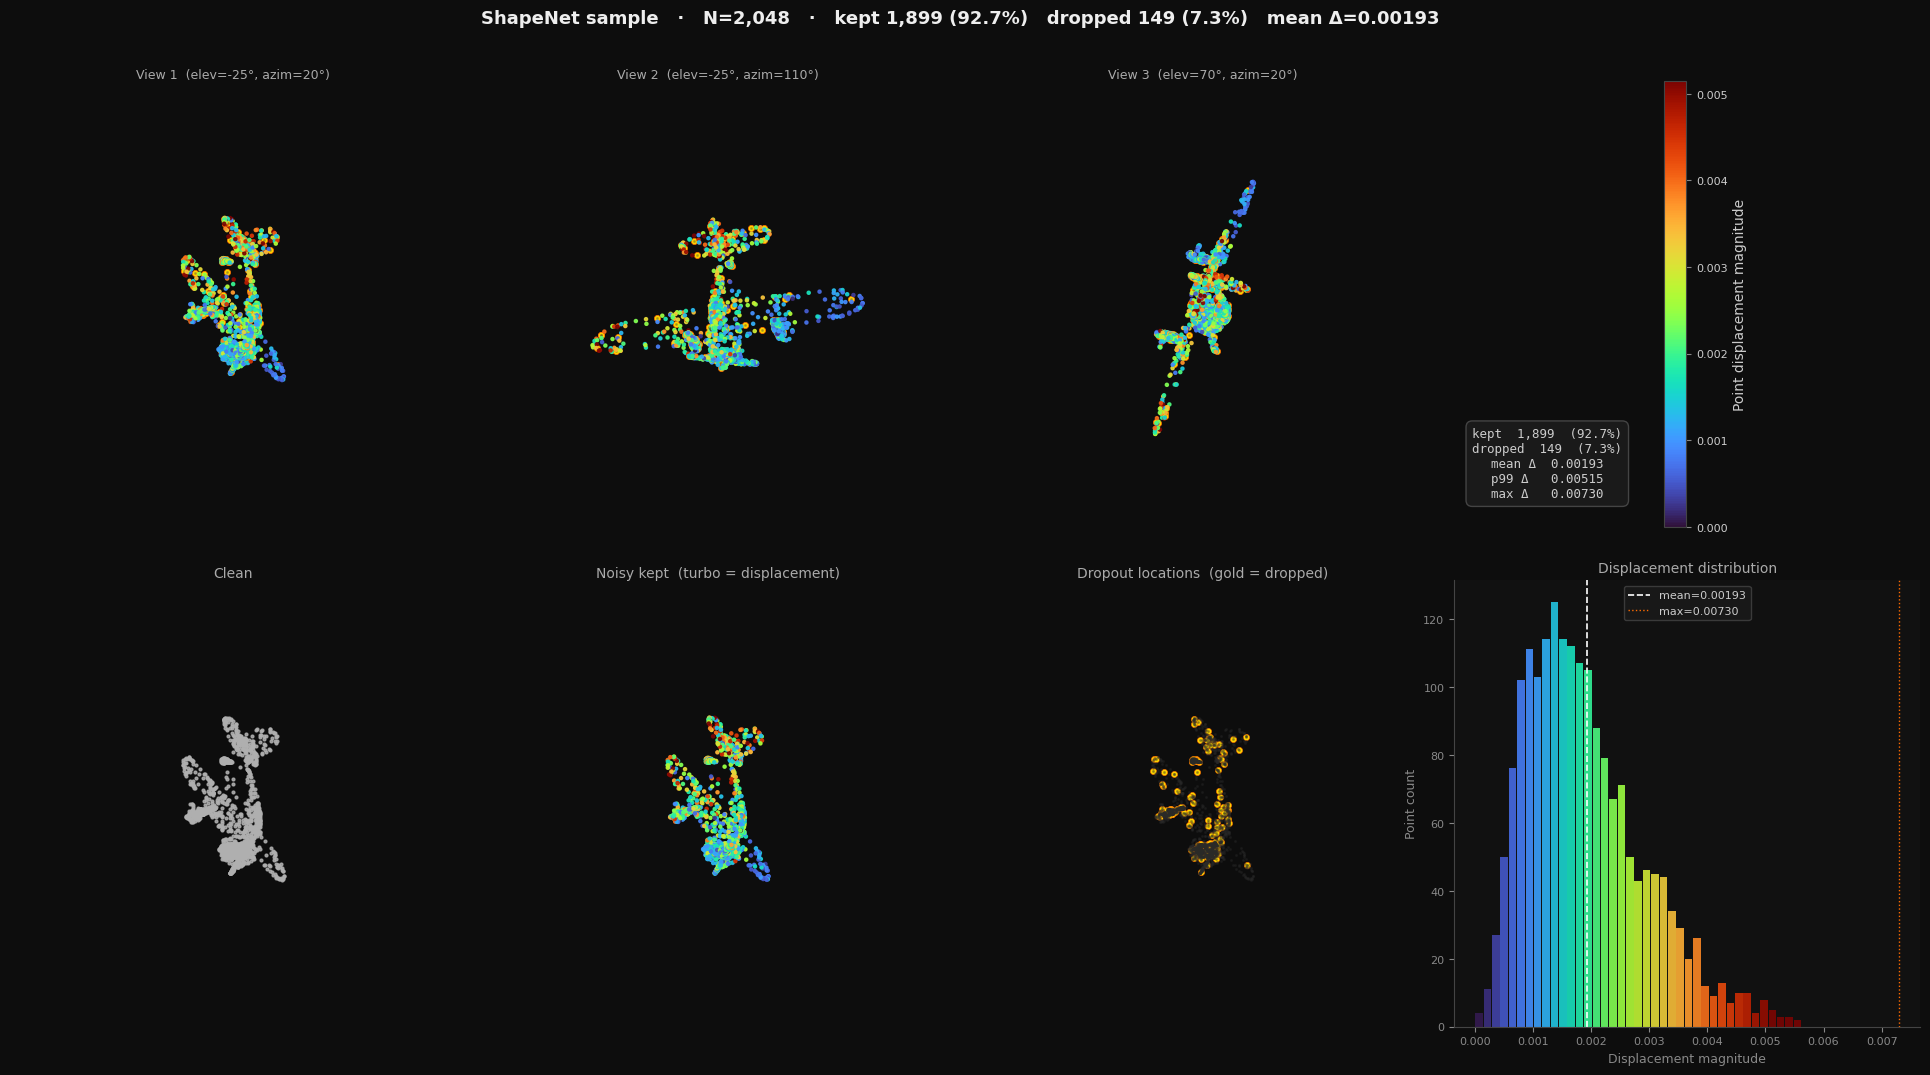

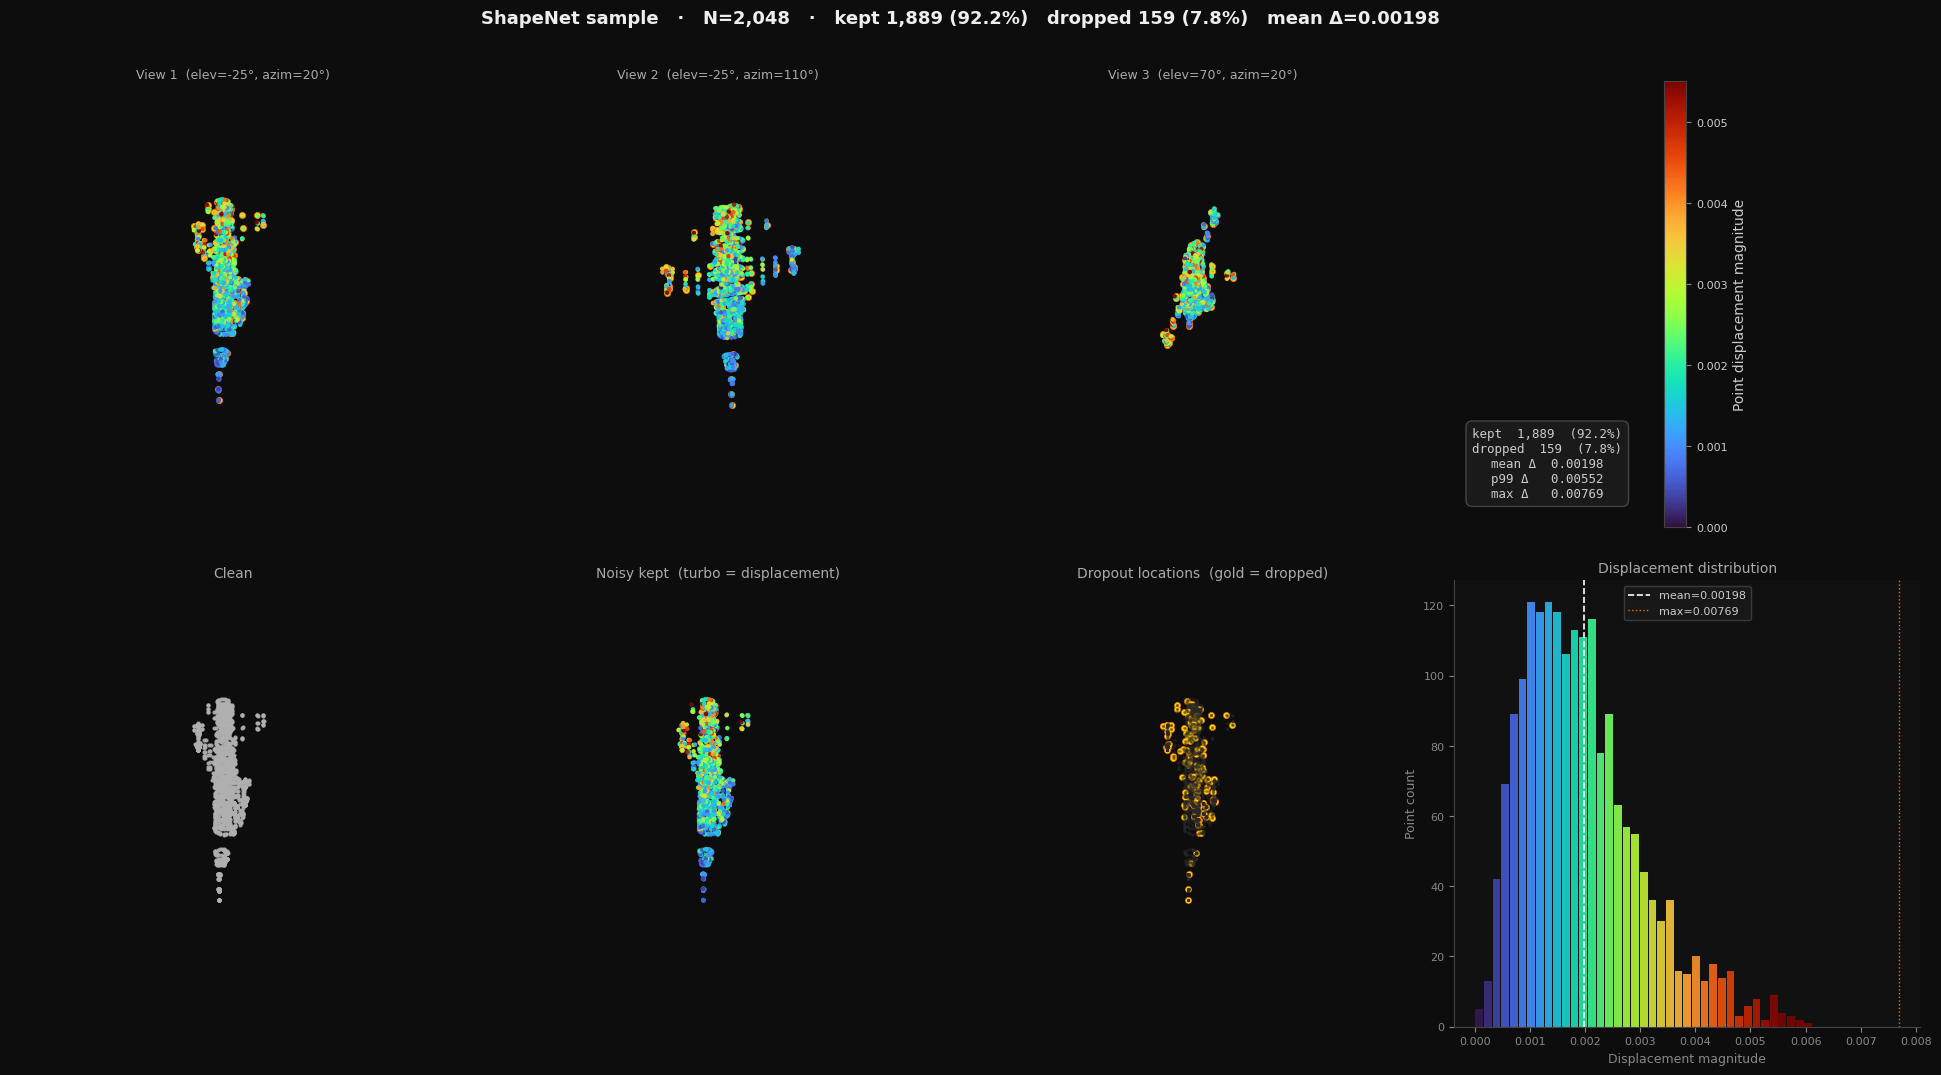

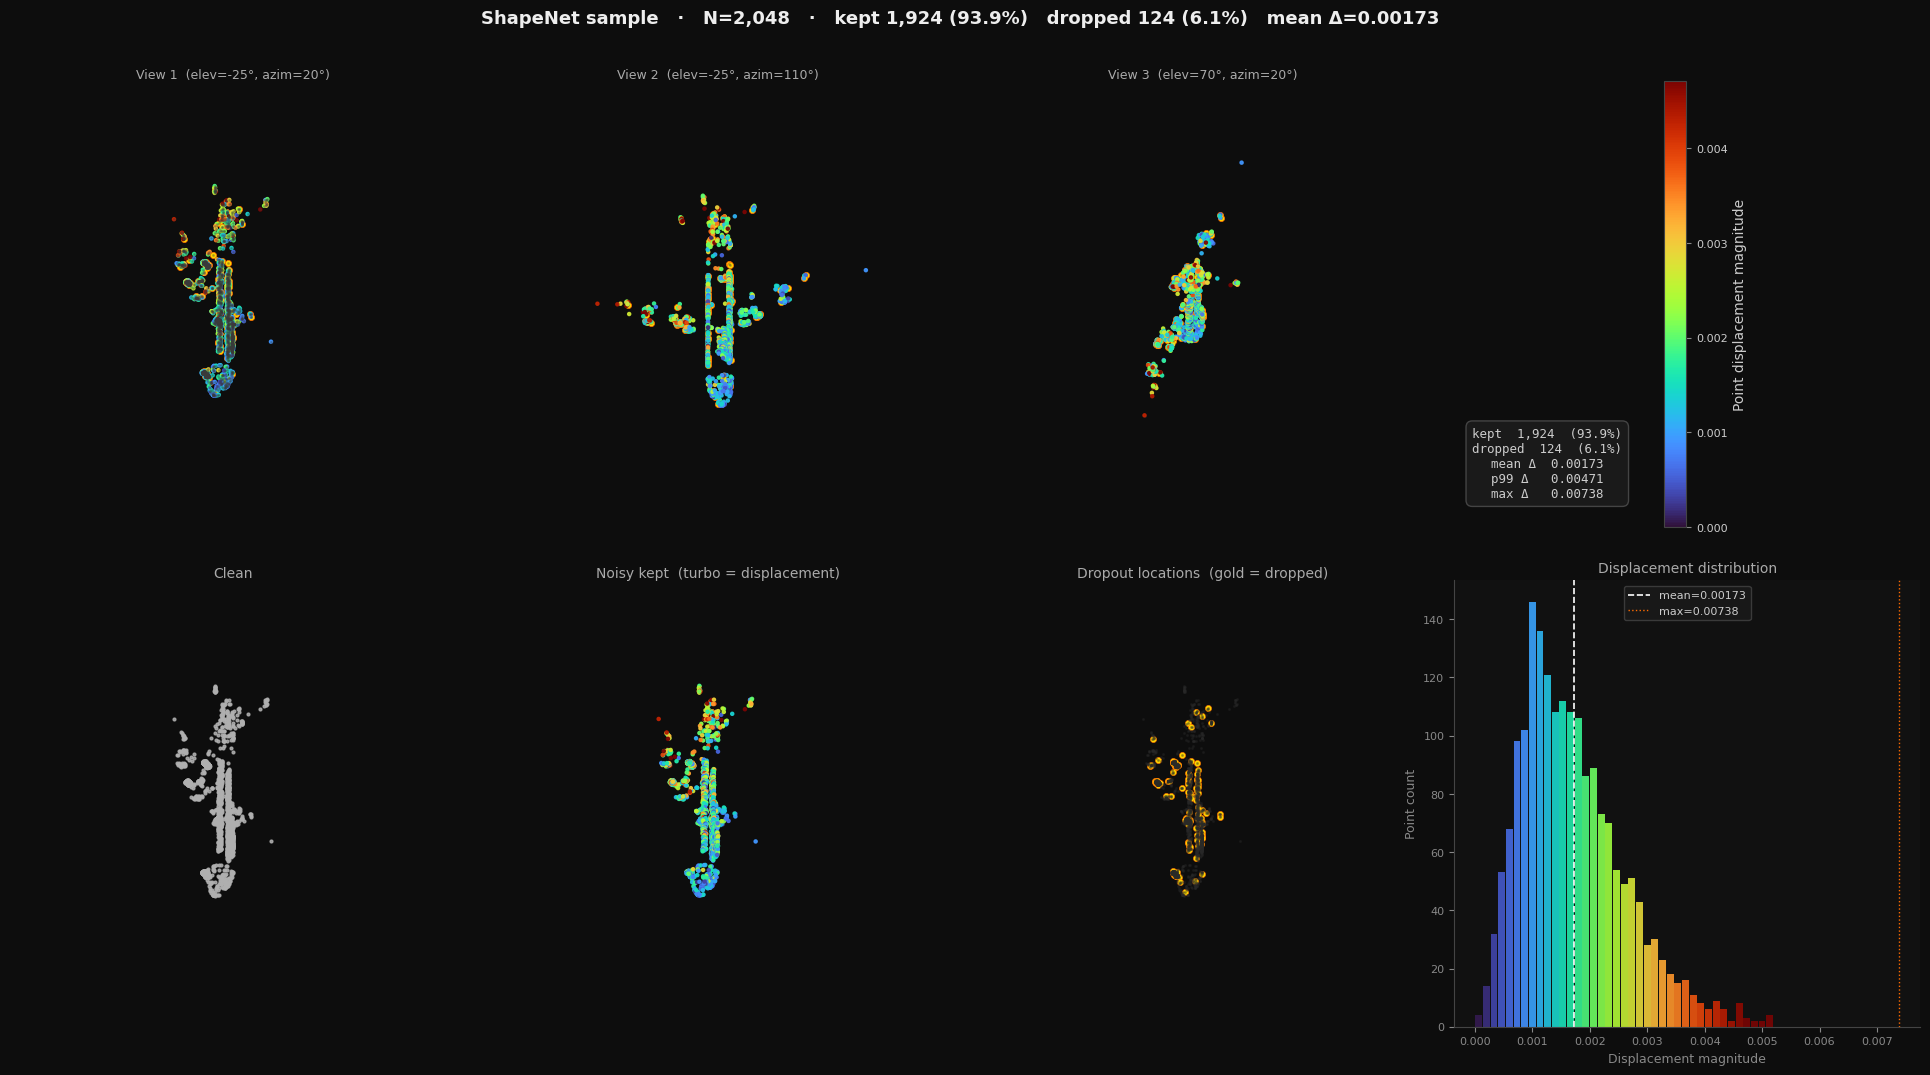

In [12]:
# ── Kinect noise visualization ────────────────────────────────────────────────
def set_axes_equal(ax, pts):
    if torch.is_tensor(pts):
        pts = pts.detach().cpu().numpy()
    mins = pts.min(axis=0); maxs = pts.max(axis=0)
    c = (mins + maxs) / 2.0
    r = (maxs - mins).max() / 2.0 + 1e-8
    ax.set_xlim(c[0]-r, c[0]+r)
    ax.set_ylim(c[1]-r, c[1]+r)
    ax.set_zlim(c[2]-r, c[2]+r)

def _class_name(ds, label):
    if isinstance(ds, ModelNet40Dataset):   return MN40_CLASSES[label]
    if isinstance(ds, ScanObjectNNDataset): return SCANOBJECTNN_CLASSES[label]
    if isinstance(ds, ShapeNetCoreDataset): return "ShapeNet sample"
    return f"class {label}"

def visualize_kinect_noise(dataset, idx=0, fps_n=256, seed=None):
    """
    6-panel figure:
      Row 1 — three viewpoints: clean (gray) + noisy (turbo heatmap) + dropped (yellow)
      Row 2 — [clean only] [noisy kept, turbo] [dropped only]
              + a displacement histogram as a 4th inset

    apply_kinect_noise is called directly so we can reconstruct the view vector
    and show per-point displacement detail.
    """
    if seed is not None:
        torch.manual_seed(seed)

    clean_pc, label = dataset[idx]
    name = _class_name(dataset, label)

    pc_in = clean_pc.unsqueeze(0)                          # (1, N, 3)
    noisy_pc, keep_mask = apply_kinect_noise(pc_in)

    clean  = clean_pc.cpu()                                # (N, 3)
    noisy  = noisy_pc.squeeze(0).cpu()                     # (N, 3)
    keep   = keep_mask.squeeze(0).squeeze(-1).cpu()        # (N,)  bool
    drop   = ~keep

    disp_all  = (noisy - clean).norm(dim=1)                # (N,)
    disp_kept = disp_all[keep]

    n_keep = keep.sum().item()
    n_drop = drop.sum().item()
    n_tot  = keep.numel()
    drop_pct = 100 * n_drop / n_tot
    mean_d = disp_kept.mean().item() if keep.any() else 0.0
    max_d  = disp_kept.max().item()  if keep.any() else 0.0

    # ── Colormap for displacement ─────────────────────────────────────────────
    norm = mcolors.Normalize(vmin=0, vmax=float(disp_kept.quantile(0.99)) + 1e-8)
    cmap = plt.cm.turbo

    # ── Layout: 2 rows × 4 cols, last col of row 2 = histogram ──────────────
    fig = plt.figure(figsize=(20, 11))
    fig.patch.set_facecolor('#0d0d0d')

    gs = gridspec.GridSpec(
        2, 4,
        figure=fig,
        wspace=0.04, hspace=0.12,
        left=0.02, right=0.98, top=0.90, bottom=0.04
    )

    VIEWS = [(-25, 20), (-25, 110), (70, 20)]

    # ── Row 1: three-angle overlay ────────────────────────────────────────────
    for col, (elev, azim) in enumerate(VIEWS):
        ax = fig.add_subplot(gs[0, col], projection='3d')
        ax.set_facecolor('#0d0d0d')

        # Clean cloud — very faint
        ax.scatter(
            clean[:, 0], clean[:, 1], clean[:, 2],
            c='#3a3a3a', s=1.5, alpha=0.25, depthshade=False, rasterized=True
        )
        # Noisy kept — turbo heatmap
        if keep.any():
            colors = cmap(norm(disp_kept.numpy()))
            ax.scatter(
                noisy[keep, 0], noisy[keep, 1], noisy[keep, 2],
                c=colors, s=5, alpha=0.9, depthshade=False, rasterized=True
            )
        # Dropped — bright yellow with outline
        if drop.any():
            ax.scatter(
                clean[drop, 0], clean[drop, 1], clean[drop, 2],
                c='#FFD700', edgecolors='#FF6B00', linewidths=0.5,
                s=20, alpha=1.0, depthshade=False, zorder=5
            )

        ax.view_init(elev=elev, azim=azim)
        ax.set_axis_off()
        set_axes_equal(ax, clean)
        ax.set_title(
            f'View {col+1}  (elev={elev}°, azim={azim}°)',
            color='#aaaaaa', fontsize=9, pad=2
        )

    # Row 1, col 3 — colorbar panel (plain axes)
    ax_cb = fig.add_subplot(gs[0, 3])
    ax_cb.set_facecolor('#0d0d0d')
    ax_cb.set_axis_off()
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cb = fig.colorbar(sm, ax=ax_cb, orientation='vertical', fraction=0.55, pad=0.05)
    cb.set_label('Point displacement magnitude', color='#cccccc', fontsize=10)
    cb.ax.yaxis.set_tick_params(color='#888888')
    plt.setp(cb.ax.yaxis.get_ticklabels(), color='#cccccc', fontsize=8)
    cb.outline.set_edgecolor('#444444')
    ax_cb.text(0.5, 0.06,
               f'kept  {n_keep:,}  ({100-drop_pct:.1f}%)\n'
               f'dropped  {n_drop:,}  ({drop_pct:.1f}%)\n'
               f'mean Δ  {mean_d:.5f}\n'
               f'p99 Δ   {disp_kept.quantile(0.99).item():.5f}\n'
               f'max Δ   {max_d:.5f}',
               transform=ax_cb.transAxes,
               ha='center', va='bottom',
               fontsize=9, color='#cccccc',
               fontfamily='monospace',
               bbox=dict(boxstyle='round,pad=0.5', facecolor='#1a1a1a', edgecolor='#444444'))

    # ── Row 2, col 0: clean ───────────────────────────────────────────────────
    ax4 = fig.add_subplot(gs[1, 0], projection='3d')
    ax4.set_facecolor('#0d0d0d')
    ax4.scatter(
        clean[:, 0], clean[:, 1], clean[:, 2],
        c='#b0b0b0', s=4, alpha=0.85, depthshade=False, rasterized=True
    )
    ax4.view_init(elev=-25, azim=20)
    ax4.set_axis_off()
    set_axes_equal(ax4, clean)
    ax4.set_title('Clean', color='#aaaaaa', fontsize=10, pad=2)

    # ── Row 2, col 1: noisy kept — displacement heatmap ──────────────────────
    ax5 = fig.add_subplot(gs[1, 1], projection='3d')
    ax5.set_facecolor('#0d0d0d')
    if keep.any():
        colors = cmap(norm(disp_kept.numpy()))
        ax5.scatter(
            noisy[keep, 0], noisy[keep, 1], noisy[keep, 2],
            c=colors, s=5, alpha=0.92, depthshade=False, rasterized=True
        )
    ax5.view_init(elev=-25, azim=20)
    ax5.set_axis_off()
    set_axes_equal(ax5, clean)
    ax5.set_title('Noisy kept  (turbo = displacement)', color='#aaaaaa', fontsize=10, pad=2)

    # ── Row 2, col 2: dropped points in original cloud context ───────────────
    ax6 = fig.add_subplot(gs[1, 2], projection='3d')
    ax6.set_facecolor('#0d0d0d')
    # faint clean background
    ax6.scatter(
        clean[:, 0], clean[:, 1], clean[:, 2],
        c='#2a2a2a', s=1.5, alpha=0.3, depthshade=False, rasterized=True
    )
    if drop.any():
        ax6.scatter(
            clean[drop, 0], clean[drop, 1], clean[drop, 2],
            c='#FFD700', edgecolors='#FF6B00', linewidths=0.4,
            s=20, alpha=1.0, depthshade=False, zorder=5
        )
    ax6.view_init(elev=-25, azim=20)
    ax6.set_axis_off()
    set_axes_equal(ax6, clean)
    ax6.set_title('Dropout locations  (gold = dropped)', color='#aaaaaa', fontsize=10, pad=2)

    # ── Row 2, col 3: displacement histogram ─────────────────────────────────
    ax7 = fig.add_subplot(gs[1, 3])
    ax7.set_facecolor('#111111')
    ax7.spines['bottom'].set_color('#444444')
    ax7.spines['left'].set_color('#444444')
    ax7.spines['top'].set_visible(False)
    ax7.spines['right'].set_visible(False)
    ax7.tick_params(colors='#888888', labelsize=8)

    if keep.any():
        vals = disp_kept.numpy()
        bins = np.linspace(0, np.quantile(vals, 0.995), 40)
        n_hist, edges = np.histogram(vals, bins=bins)
        bin_centers = (edges[:-1] + edges[1:]) / 2
        # Color bars by turbo colormap
        bar_colors = cmap(norm(bin_centers))
        ax7.bar(bin_centers, n_hist, width=(edges[1]-edges[0])*0.9,
                color=bar_colors, alpha=0.9, linewidth=0)
        ax7.axvline(mean_d, color='white', lw=1.2, ls='--',
                    label=f'mean={mean_d:.5f}')
        ax7.axvline(max_d, color='#FF6B00', lw=1.0, ls=':',
                    label=f'max={max_d:.5f}')
        ax7.legend(fontsize=8, labelcolor='#cccccc',
                   facecolor='#1a1a1a', edgecolor='#444444')

    ax7.set_xlabel('Displacement magnitude', color='#888888', fontsize=9)
    ax7.set_ylabel('Point count', color='#888888', fontsize=9)
    ax7.set_title('Displacement distribution', color='#aaaaaa', fontsize=10)
    ax7.xaxis.label.set_color('#888888')
    for label_ in ax7.get_xticklabels() + ax7.get_yticklabels():
        label_.set_color('#888888')

    # ── Supertitle ────────────────────────────────────────────────────────────
    fig.suptitle(
        f'{name}   ·   N={n_tot:,}   ·   '
        f'kept {n_keep:,} ({100-drop_pct:.1f}%)   '
        f'dropped {n_drop:,} ({drop_pct:.1f}%)   '
        f'mean Δ={mean_d:.5f}',
        color='#eeeeee', fontsize=13, fontweight='bold', y=0.965
    )

    plt.show()
    return fig


# ── Run on a few samples ──────────────────────────────────────────────────────
ds = ShapeNetCoreDataset(SHAPENET_DIR)
# ds = ModelNet40Dataset(MODELNET40_DIR, 'test')
# ds = ScanObjectNNDataset('test')
for idx in [0, 3, 7]:
    visualize_kinect_noise(ds, idx=idx, seed=42)

## Network

### PointBERT transformer encoder

In [13]:
class _Mlp(nn.Module):
    def __init__(self, d, hidden=None, drop=0.):
        super().__init__()
        h = hidden or d

        # Breaking out the layers explicitly to match the pre-trained names
        self.fc1 = nn.Linear(d, h)
        self.act = nn.GELU()
        self.fc2 = nn.Linear(h, d)
        self.drop = nn.Dropout(drop)

    def forward(self, x):
        # Passing the data through step-by-step
        x = self.fc1(x)
        x = self.act(x)
        x = self.drop(x)
        x = self.fc2(x)
        x = self.drop(x)
        return x

class _Attention(nn.Module):
    def __init__(self, dim, heads=8, attn_drop=0., proj_drop=0.):
        super().__init__()
        self.heads = heads; self.scale = (dim//heads)**-0.5
        self.qkv   = nn.Linear(dim, dim*3, bias=False)
        self.drop  = nn.Dropout(attn_drop)
        self.proj  = nn.Linear(dim, dim)
        self.pdrop = nn.Dropout(proj_drop)

    def forward(self, x):
        B, N, C = x.shape
        q,k,v = self.qkv(x).reshape(B,N,3,self.heads,C//self.heads).permute(2,0,3,1,4).unbind(0)
        attn  = self.drop((q @ k.transpose(-2,-1)) * self.scale)
        return self.pdrop(self.proj((attn.softmax(-1) @ v).transpose(1,2).reshape(B,N,C)))

class _Block(nn.Module):
    def __init__(self, dim, heads, drop_path=0.):
        super().__init__()
        self.norm1  = nn.LayerNorm(dim)
        self.attn = _Attention(dim, heads)
        self.dp  = DropPath(drop_path) if drop_path > 0 else nn.Identity()
        self.norm2  = nn.LayerNorm(dim)
        self.mlp = _Mlp(dim, dim*4)

    def forward(self, x):
        x = x + self.dp(self.attn(self.norm1(x)))
        return x + self.dp(self.mlp(self.norm2(x)))

class PointTransformerEncoder(nn.Module):
    """(B,N,3) -> (B, TRANS_DIM*2), compatible with ULIP-2 PointBERT weights."""
    def __init__(self):
        super().__init__()
        self.group_divider = Group(NUM_GROUP, GROUP_SIZE)
        self.encoder       = PatchEncoder(ENC_DIMS)
        self.reduce_dim    = nn.Linear(ENC_DIMS, TRANS_DIM)
        self.cls_token     = nn.Parameter(torch.zeros(1, 1, TRANS_DIM))
        self.cls_pos       = nn.Parameter(torch.randn(1, 1, TRANS_DIM))
        self.pos_embed     = nn.Sequential(nn.Linear(3,128), nn.GELU(), nn.Linear(128, TRANS_DIM))
        dpr = torch.linspace(0, DROP_PATH, DEPTH).tolist()
        self.blocks        = nn.ModuleList([_Block(TRANS_DIM, NUM_HEADS, dpr[i]) for i in range(DEPTH)])
        self.norm          = nn.LayerNorm(TRANS_DIM)

    def forward(self, pts):
        nb, center = self.group_divider(pts)
        tok = self.reduce_dim(self.encoder(nb))              # B G D
        B   = pts.shape[0]
        x   = torch.cat([self.cls_token.expand(B,-1,-1), tok], 1)
        pos = torch.cat([self.cls_pos.expand(B,-1,-1), self.pos_embed(center)], 1)
        for blk in self.blocks:
            x = blk(x + pos)
        x = self.norm(x)
        return torch.cat([x[:,0], x[:,1:].max(1)[0]], -1)   # B, D*2

print('PointTransformerEncoder defined.')

PointTransformerEncoder defined.


### ULIP-2 encoder (3D + text)

In [14]:
class _QuickGELU(nn.Module):
    """CLIP's original activation, must match pretrained text encoder weights."""
    def forward(self, x): return x * torch.sigmoid(1.702 * x)

class _TextBlock(nn.Module):
    """One CLIP transformer block (batch-first wrapper)."""
    def __init__(self, d, heads, ctx):
        super().__init__()
        self.attn = nn.MultiheadAttention(d, heads, batch_first=False)
        self.ln1  = nn.LayerNorm(d)
        self.mlp  = nn.Sequential(nn.Linear(d, d*4), _QuickGELU(), nn.Linear(d*4, d))
        self.ln2  = nn.LayerNorm(d)
        mask = torch.empty(ctx, ctx).fill_(float('-inf')).triu_(1)
        self.register_buffer('mask', mask)

    def forward(self, x):                                    # x: (B, seq, d)
        a = self.ln1(x).permute(1,0,2)                      # seq-first for MHA
        a = self.attn(a, a, a, attn_mask=self.mask.to(x.dtype))[0].permute(1,0,2)
        x = x + a
        return x + self.mlp(self.ln2(x))

class ULIP2Encoder(nn.Module):
    """Frozen ULIP-2 PointBERT + CLIP text encoder from official checkpoint."""
    def __init__(self, checkpoint_path):
        super().__init__()
        print('Loading ULIP-2 checkpoint…')
        ckpt = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
        sd   = OrderedDict((k.replace('module.',''), v) for k,v in ckpt['state_dict'].items())

        # 3D point encoder
        self.point_encoder = PointTransformerEncoder()

        # Extract 3D weights and fix the redundant 'blocks.blocks.' prefix natively
        pc_sd = {k.replace('point_encoder.', '').replace('blocks.blocks.', 'blocks.'): v
                 for k, v in sd.items() if k.startswith('point_encoder.')}

        # STRICT LOADING ENFORCED
        self.point_encoder.load_state_dict(pc_sd, strict=True)
        print("3D Encoder weights loaded perfectly!")

        self.pc_projection = nn.Parameter(sd['pc_projection'].clone())   # (768, 512)

        # Text encoder, infer arch from checkpoint
        tw    = sd['text_projection'].shape[0]        # transformer_width (512 for ViT-B)
        ctx   = sd['positional_embedding'].shape[0]   # context_length (77)
        vs    = sd['token_embedding.weight'].shape[0] # vocab_size (49408)
        depth = sum(1 for k in sd
                    if k.startswith('transformer.resblocks.') and k.endswith('.ln_1.weight'))
        heads = tw // 64
        self.token_embedding      = nn.Embedding(vs, tw)
        self.positional_embedding = nn.Parameter(sd['positional_embedding'].clone())
        self.text_blocks          = nn.Sequential(*[_TextBlock(tw, heads, ctx) for _ in range(depth)])
        self.ln_final             = nn.LayerNorm(tw)
        self.text_projection      = nn.Parameter(sd['text_projection'].clone())
        self.context_length       = ctx

        self.token_embedding.weight.data.copy_(sd['token_embedding.weight'])
        self.ln_final.weight.data.copy_(sd['ln_final.weight'])
        self.ln_final.bias.data.copy_(sd['ln_final.bias'])
        for i, blk in enumerate(self.text_blocks):
            p = f'transformer.resblocks.{i}'
            if f'{p}.ln_1.weight' not in sd: p = f'transformer.{i}'
            blk.ln1.weight.data.copy_(sd[f'{p}.ln_1.weight'])
            blk.ln1.bias.data.copy_(sd[f'{p}.ln_1.bias'])
            blk.ln2.weight.data.copy_(sd[f'{p}.ln_2.weight'])
            blk.ln2.bias.data.copy_(sd[f'{p}.ln_2.bias'])
            blk.attn.in_proj_weight.data.copy_(sd[f'{p}.attn.in_proj_weight'])
            blk.attn.in_proj_bias.data.copy_(sd[f'{p}.attn.in_proj_bias'])
            blk.attn.out_proj.weight.data.copy_(sd[f'{p}.attn.out_proj.weight'])
            blk.attn.out_proj.bias.data.copy_(sd[f'{p}.attn.out_proj.bias'])
            blk.mlp[0].weight.data.copy_(sd[f'{p}.mlp.c_fc.weight'])
            blk.mlp[0].bias.data.copy_(sd[f'{p}.mlp.c_fc.bias'])
            blk.mlp[2].weight.data.copy_(sd[f'{p}.mlp.c_proj.weight'])
            blk.mlp[2].bias.data.copy_(sd[f'{p}.mlp.c_proj.bias'])

        self.tokenizer = open_clip.get_tokenizer('ViT-B-32')

        # Lock the entire encoder down in evaluation mode
        self.eval()
        self.point_encoder.eval()
        for p in self.parameters():
            p.requires_grad_(False)

        print(f'ULIP-2 ready  |  text depth={depth} heads={heads}  '
              f'3D params={sum(p.numel() for p in self.point_encoder.parameters()):,}')

    @torch.no_grad()
    def encode_pc(self, pc):
        return F.normalize(self.point_encoder(pc) @ self.pc_projection, dim=-1)

    @torch.no_grad()
    def encode_text(self, class_names, descs=None):
        """Ensemble over PROMPT_TEMPLATES. descs overrides CLASS_DESCS lookup."""
        dev = self.pc_projection.device
        d   = descs or [CLASS_DESCS.get(c, c) for c in class_names]
        feats = []
        for tmpl in PROMPT_TEMPLATES:
            toks = self.tokenizer([tmpl.format(x) for x in d]).to(dev)
            x = self.token_embedding(toks) + self.positional_embedding[:toks.shape[1]]
            x = self.text_blocks(x)
            x = self.ln_final(x)
            x = x[torch.arange(len(toks)), toks.argmax(-1)] @ self.text_projection
            feats.append(F.normalize(x, dim=-1))
        return F.normalize(torch.stack(feats).mean(0), dim=-1)

print('ULIP2Encoder defined.')

ULIP2Encoder defined.


### ULIP-2 checkpoints download

In [15]:
# ── ULIP-2 checkpoint ─────────────────────────────────────────────────────────
# Official release: github.com/salesforce/ULIP  (HuggingFace mirror: SFXX/ulip)
# We need the xyz-only (3D) variant, NOT the colored 10k variant.
_ULIP_TARGET = 'ULIP-2-PointBERT-8k-xyz-pc-slip_vit_b-objaverse-pretrained.pt'
_ULIP_HF_REPO = 'SFXX/ulip'

if not os.path.exists(ULIP2_CKPT):
    print('Locating ULIP-2 checkpoint on HuggingFace…')
    # Find the file anywhere in the repo tree
    try:
        all_files = list(list_repo_files(_ULIP_HF_REPO, repo_type='dataset'))
        candidates = [f for f in all_files if _ULIP_TARGET in f]
        if not candidates:
            # Try the simpler name that may appear in some mirrors
            candidates = [f for f in all_files
                          if 'PointBERT' in f and 'ulip' in f.lower() and 'color' not in f.lower()]
        print(f'  Candidates: {candidates}')
    except Exception as e:
        candidates = []
        print(f'  HuggingFace listing failed: {e}')

    if candidates:
        tmp = hf_hub_download(
            repo_id=_ULIP_HF_REPO, repo_type='dataset',
            filename=candidates[0],
            local_dir=f'{BASE}/models/tmp_ulip',
        )
        os.rename(tmp, ULIP2_CKPT)
        print(f'Downloaded → {ULIP2_CKPT}')
    else:
        print("""
                ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
                ULIP-2 checkpoint not found automatically.
                Manual download (one-time, ~400 MB):

                  1. Go to: https://github.com/salesforce/ULIP
                     and follow the download links in the README
                     → look for: ULIP-2-PointBERT-8k-xyz  (xyz-only, NOT colored)

                  2. Upload the .pt file to Google Drive at:
                     MyDrive/SACB/models/ulip2_pointbert.pt

                Then re-run this cell.
                ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
                """)
else:
    print(f'Checkpoint already present.')

Checkpoint already present.


### Sensor-Aware Contrastive Bridge

The following block defines the class of the **Bridge**. In case of a higher dimension of the hidden feature space, we suggest to bump up the **dropout** (as well as other hyperparameters that are underlined in the **CONSTANTS** section) to compensate for the increase of parameters (0.2 for 2048-D).

In [16]:
class SensorAwareContrastiveBridge(nn.Module):
    """3-layer MLP for Direct Latent Translation: (B,512) noisy -> (B,512) clean."""
    def __init__(self, in_dim=512, hidden_dim=1024, dropout=0.1):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_dim, in_dim)
        )

    def forward(self, x):
        # DIRECT MAPPING: no residual anchor.
        return self.net(x)

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

print(f'Bridge defined. Params: {SensorAwareContrastiveBridge().count_parameters():,}')

Bridge defined. Params: 6,304,256


## Training

### Choose variant & load

In [27]:
VARIANT = 'C'  # ← change to 'A', 'B', or 'C'

encoder = ULIP2Encoder(ULIP2_CKPT).to(device).eval()
train_loader, scan_loader, mn40_loader, shapenet_loader = get_dataloaders(VARIANT)
print(f'Variant {VARIANT} | train={len(train_loader.dataset)} '
      f'mn40-test={len(mn40_loader.dataset)}'
      + (f' scan-test={len(scan_loader.dataset)}' if scan_loader else ' (no ScanObjectNN)')
      + (f' shape-test={len(shapenet_loader.dataset)}' if shapenet_loader else ' (no ShapeNetCore)'))

Loading ULIP-2 checkpoint…
3D Encoder weights loaded perfectly!
ULIP-2 ready  |  text depth=12 heads=8  3D params=21,858,816
Training source: MODELNET40 (9,840 objects)
Training source: SCANOBJECTNN (2,309 objects)
ShapeNetCore: 51,556 point clouds loaded from HDF5
Starting ShapeNet classes filtering (train/eval split)...
Filtering done: 1944 eval objects (100/class x 20 classes), 3858 objects kept for training (250/class x 20 classes), out of 51556 total.
Training source: SHAPENETCORE (3,858 objects)
Variant B | train=16007 mn40-test=2468 scan-test=581 shape-test=1944


### Train

In [28]:
trainer = Trainer(VARIANT, encoder)

for epoch in range(1, NUM_EPOCHS + 1):
    loss = trainer.train_epoch(train_loader)
    print(f'Epoch {epoch:3d}/{NUM_EPOCHS}  loss={loss:.4f}')
    if epoch % 5 == 0 or epoch == NUM_EPOCHS:
        ckpt = trainer.save(epoch)
        print(f'  → {ckpt}')

print('Training complete.')

[Trainer] variant=B  bridge params=6,304,256


  0%|          | 0/250 [00:00<?, ?it/s]

Epoch   1/30  loss=3.1488


  0%|          | 0/250 [00:00<?, ?it/s]

Epoch   2/30  loss=0.8754


...

Epoch  28/30  loss=0.4364


  0%|          | 0/250 [00:00<?, ?it/s]

Epoch  29/30  loss=0.4392


  0%|          | 0/250 [00:00<?, ?it/s]

Epoch  30/30  loss=0.4391
  → /content/drive/MyDrive/SACB/checkpoints/sacb_variantB_epoch030.pt
Training complete.


## Evaluation

### Evaluate


In [29]:
bridge = trainer.bridge.eval()

scan_base, scan_base_pc, _        = evaluate(None,   encoder, scan_loader,  SCANOBJECTNN_CLASSES,     VARIANT)
mn40_base, mn40_base_pc, _        = evaluate(None,   encoder, mn40_loader,  MN40_CLASSES,             VARIANT)
shape_base, shape_base_pc, _        = evaluate(None,   encoder, shapenet_loader, SHAPENET_CLASSES,    VARIANT)
scan_br,   scan_br_pc,   scan_cd   = evaluate(bridge, encoder, scan_loader,     SCANOBJECTNN_CLASSES, VARIANT)
mn40_br,   mn40_br_pc,   mn40_cd   = evaluate(bridge, encoder, mn40_loader,     MN40_CLASSES,         VARIANT)
shape_br,   shape_br_pc,   shape_cd = evaluate(bridge, encoder, shapenet_loader, SHAPENET_CLASSES,    VARIANT)

print('\n=== Results ===')
if scan_base is not None:
    print(f'ScanObjectNN  baseline: {scan_base:.2f}%   bridge: {scan_br:.2f}%   '
          f'Δ={scan_br-scan_base:+.2f}pp   CD={scan_cd:.4f}')
print(f'ModelNet40    baseline: {mn40_base:.2f}%   bridge: {mn40_br:.2f}%   '
      f'Δ={mn40_br-mn40_base:+.2f}pp   CD={mn40_cd:.4f}')
if shape_base is not None:
    print(f'ShapeNet      baseline: {shape_base:.2f}%   bridge: {shape_br:.2f}%   '
          f'Δ={shape_br-shape_base:+.2f}pp   CD={shape_cd:.4f}')


=== Results ===
ScanObjectNN  baseline: 37.18%   bridge: 46.47%   Δ=+9.29pp   CD=0.5977
ModelNet40    baseline: 71.60%   bridge: 70.34%   Δ=-1.26pp   CD=0.5076
ShapeNet      baseline: 16.46%   bridge: 14.40%   Δ=-2.06pp   CD=0.5652


### Visualizations

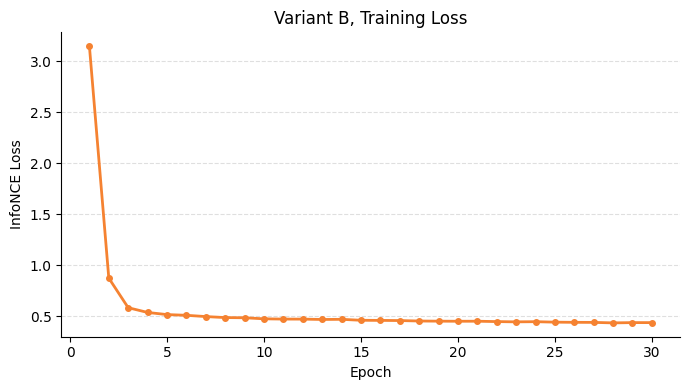

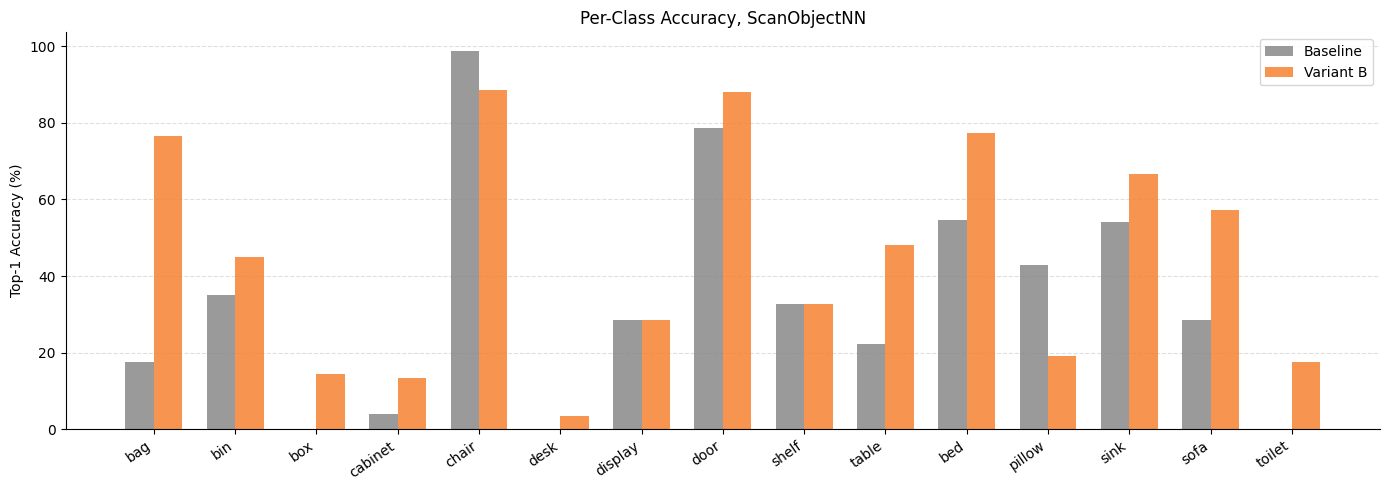

Mean per-class: baseline=33.2%  bridge=45.1%


In [30]:
os.makedirs(RESULTS_DIR, exist_ok=True)

# Loss curve
fig, ax = plt.subplots(figsize=(7,4))
ax.plot(range(1, len(trainer.history)+1), trainer.history,
        color='#f58231', lw=2, marker='o', markersize=4)
ax.set_xlabel('Epoch'); ax.set_ylabel('InfoNCE Loss')
ax.set_title(f'Variant {VARIANT}, Training Loss')
ax.yaxis.grid(True, ls='--', alpha=0.4)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
fig.tight_layout()
fig.savefig(f'{RESULTS_DIR}/loss_variant{VARIANT}.png', dpi=150)
plt.show()

# Per-class accuracy bar chart
if scan_br_pc is not None:
    x = np.arange(len(SCANOBJECTNN_CLASSES)); w = 0.35
    fig, ax = plt.subplots(figsize=(14,5))
    ax.bar(x - w/2, scan_base_pc, w, color='#888',    alpha=0.85, label='Baseline')
    ax.bar(x + w/2, scan_br_pc,   w, color='#f58231', alpha=0.85, label=f'Variant {VARIANT}')
    ax.set_xticks(x); ax.set_xticklabels(SCANOBJECTNN_CLASSES, rotation=35, ha='right')
    ax.set_ylabel('Top-1 Accuracy (%)'); ax.legend()
    ax.set_title('Per-Class Accuracy, ScanObjectNN')
    ax.yaxis.grid(True, ls='--', alpha=0.4); ax.set_axisbelow(True)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    fig.tight_layout()
    fig.savefig(f'{RESULTS_DIR}/perclass_variant{VARIANT}.png', dpi=150)
    plt.show()
    print(f'Mean per-class: baseline={scan_base_pc.mean():.1f}%  bridge={scan_br_pc.mean():.1f}%')

### Ablation table
Run after training all three variants (re-run **Training** block and **Evaluate** cell with `VARIANT='A'`, `'B'`, `'C'`).

In [31]:
results = {}
for var in ['A', 'B', 'C']:
    ckpt_path = f'{CHECKPOINTS_DIR}/sacb_variant{var}_epoch{NUM_EPOCHS:03d}.pt'
    if not os.path.exists(ckpt_path):
        print(f'Variant {var}: checkpoint not found, skipping'); continue
    br = load_bridge(ckpt_path)
    s_acc,  _, s_cd  = evaluate(br, encoder, scan_loader,     SCANOBJECTNN_CLASSES, var)
    m_acc,  _, m_cd  = evaluate(br, encoder, mn40_loader,     MN40_CLASSES,         var)
    sn_acc, _, sn_cd = evaluate(br, encoder, shapenet_loader, SHAPENET_CLASSES,     var)
    results[var] = dict(scan=s_acc, mn40=m_acc, shape=sn_acc, cd=s_cd)

print(f'{"Variant":<12} {"ScanObjNN":>10} {"ModelNet40":>11} {"ShapeNet":>9} {"CD (feat)":>10}')
print('-' * 57)
if scan_base is not None:
    print(f'{"baseline":<12} {scan_base:>9.2f}% {mn40_base:>10.2f}% {shape_base:>8.2f}%          —')
for var, r in results.items():
    s  = f"{r['scan']:.2f}%"  if r['scan']  is not None else '—'
    m  = f"{r['mn40']:.2f}%"  if r['mn40']  is not None else '—'
    sn = f"{r['shape']:.2f}%" if r['shape'] is not None else '—'
    c  = f"{r['cd']:.4f}"     if r['cd']    is not None else '—'
    print(f'{var:<12} {s:>10} {m:>11} {sn:>9} {c:>10}')

Variant       ScanObjNN  ModelNet40  ShapeNet  CD (feat)
---------------------------------------------------------
baseline         37.18%      71.60%    16.46%          —
A                43.72%      70.62%    14.87%     1.0386
B                45.96%      70.42%    14.56%     0.5985
C                42.51%      70.66%    14.20%     0.6086
